In [278]:
from google.colab import files
uploaded = files.upload()

Saving IPL_2008-2024_data.csv to IPL_2008-2024_data (3).csv


In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
df = pd.read_csv("IPL_2008-2024_data.csv")

In [281]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [283]:
df.isna().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


# Question 1: Data Preprocessing & Feature Engineering

Handle missing values appropriately

In [284]:
venue_city_map = df.dropna(subset=['city']).groupby('venue')['city'].agg(lambda x: x.mode()[0]).to_dict()

df['city'] = df.apply(
    lambda x: venue_city_map[x['venue']] if pd.isnull(x['city']) else x['city'],
    axis=1
)

Missing values in the city column were imputed using a venue-to-city mapping derived from existing data. Since each venue corresponds to a fixed geographic location, this approach preserves real-world consistency. Any remaining missing values were labeled as “Unknown” to avoid incorrect assumptions.

In [285]:
df['city'].isna().sum()

np.int64(0)

In [286]:
df['player_of_match'] = df['player_of_match'].fillna('None')

The player_of_match column is not critical for match outcome prediction. Missing values were replaced with “None” to retain rows without introducing artificial bias.

In [287]:
df = df[df['winner'].notna()]

Rows with missing winner values were removed as the target variable is essential for both analysis and predictive modeling. Imputing this field would introduce incorrect labels and compromise model integrity.

In [288]:
df.isna().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


In [289]:
df['result_margin'] = df['result_margin'].fillna(0)

Missing values in result_margin occur in cases such as ties, no-results, or matches decided by super over. These were filled with 0 to represent edge cases without distorting the distribution of winning margins.

In [290]:
df['method'] = df['method'].fillna('Normal')

The method column indicates special match conditions such as rain interruptions (e.g., DLS method). Since the majority of matches are played under normal conditions, missing values were replaced with “Normal” to explicitly encode the absence of interruptions.

In [291]:
df.isna().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


In [292]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,Normal,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Normal,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,Normal,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,Normal,BF Bowden,K Hariharan


Creating new features

In [293]:
df['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [294]:
team_name_map = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',

    'Rising Pune Supergiants': 'Rising Pune Supergiant',

    'Deccan Chargers': 'Sunrisers Hyderabad'
}

cols = ['team1', 'team2', 'winner', 'toss_winner']

for col in cols:
    df[col] = df[col].replace(team_name_map)

In [295]:
df['team1'].unique()

array(['Royal Challengers Bengaluru', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Sunrisers Hyderabad', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Lucknow Super Giants', 'Gujarat Titans'],
      dtype=object)

In [296]:
df['city'].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', 'Sharjah', 'Dubai', 'Rajkot', 'Kanpur', 'Bengaluru',
       'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'], dtype=object)

In [297]:
def clean_city_names(city):
    mapping = {
        'Bangalore': 'Bengaluru',
        'Chandigarh': 'Mohali'
    }
    return mapping.get(city, city)

df['city'] = df['city'].apply(clean_city_names)

In [298]:
df['city'].unique()

array(['Bengaluru', 'Mohali', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', 'Sharjah', 'Dubai', 'Rajkot', 'Kanpur', 'Navi Mumbai',
       'Lucknow', 'Guwahati'], dtype=object)

In [299]:
df['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

In [300]:
venue_map = {
    # Bangalore
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',

    # Delhi
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',

    # Mumbai
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',

    # Chennai
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',

    # Hyderabad
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',

    # Punjab
    'Punjab Cricket Association Stadium, Mohali': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'PCA Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'PCA Stadium',

    # Ahmedabad
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium',

    # Kolkata
    'Eden Gardens, Kolkata': 'Eden Gardens',

    # Pune
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',

    # Visakhapatnam
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam':
        'ACA-VDCA Cricket Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium':
        'ACA-VDCA Cricket Stadium'
}

df['venue'] = df['venue'].replace(venue_map)

In [301]:
df['venue'].unique()

array(['M Chinnaswamy Stadium', 'PCA Stadium', 'Arun Jaitley Stadium',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium',
       'Dr DY Patil Sports Academy', 'Newlands', "St George's Park",
       'Kingsmead', 'SuperSport Park', 'Buffalo Park',
       'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium', 'Narendra Modi Stadium',
       'Barabati Stadium', 'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium', 'ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sheikh Zayed Stadium',
       'Sharjah Cricket Stadium', 'Dubai International Cricket Stadium',
    

In [302]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

Home_advantage: Boolean indicating if team1 is playing in their home city

In [303]:
team_home_city = {
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bengaluru': 'Bengaluru',
    'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi',
    'Punjab Kings': 'Mohali',
    'Rajasthan Royals': 'Jaipur',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Lucknow Super Giants': 'Lucknow',
    'Gujarat Titans': 'Ahmedabad',
    'Kochi Tuskers Kerala': 'Kochi',
    'Pune Warriors' : 'Pune',
    'Gujarat Lions' : 'Rajkot',
    'Rising Pune Supergiant' : 'Pune',
}

df['home_advantage'] = df.apply(
    lambda x: x['city'] == team_home_city.get(x['team1'], None),
    axis=1
)

venue_matches_team1_prior / venue_matches_team2_prior: number of matches the team has played at this same venue before the current match date

In [304]:
from collections import defaultdict

venue_team_count = defaultdict(int)

df['venue_matches_team1_prior'] = 0
df['venue_matches_team2_prior'] = 0

for i, row in df.iterrows():
    key1 = (row['team1'], row['venue'])
    key2 = (row['team2'], row['venue'])

    df.at[i, 'venue_matches_team1_prior'] = venue_team_count[key1]
    df.at[i, 'venue_matches_team2_prior'] = venue_team_count[key2]

    venue_team_count[key1] += 1
    venue_team_count[key2] += 1

match_importance: Categorical (league/playoff/final) based on date and season

In [305]:
def get_match_importance(match_type):
    match_type = match_type.lower()

    if match_type == 'league':
        return 'League'
    elif 'final' in match_type:
        return 'Final'
    else:
        return 'Playoff'

df['match_importance'] = df['match_type'].apply(get_match_importance)

toss_advantage: Whether toss winner won the match

In [306]:
df['toss_advantage'] = df['toss_winner'] == df['winner']

season_phase: Early/Mid/Late season

In [307]:
df['match_number'] = df.groupby('season').cumcount() + 1
df['total_matches'] = df.groupby('season')['id'].transform('count')

def get_phase(row):
    if row['match_number'] <= 0.3 * row['total_matches']:
        return 'Early'
    elif row['match_number'] <= 0.7 * row['total_matches']:
        return 'Mid'
    else:
        return 'Late'

df['season_phase'] = df.apply(get_phase, axis=1)

In [308]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,umpire1,umpire2,home_advantage,venue_matches_team1_prior,venue_matches_team2_prior,match_importance,toss_advantage,match_number,total_matches,season_phase
0,335982,2008,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Asad Rauf,RE Koertzen,True,0,0,League,False,1,58,Early
1,335983,2008,Mohali,2008-04-19,League,MEK Hussey,PCA Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,MR Benson,SL Shastri,True,0,0,League,True,2,58,Early
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,Aleem Dar,GA Pratapkumar,True,0,0,League,False,3,58,Early
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,SJ Davis,DJ Harper,True,0,0,League,False,4,58,Early
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,...,BF Bowden,K Hariharan,True,0,0,League,False,5,58,Early


Visualization showing distribution of matches across venues

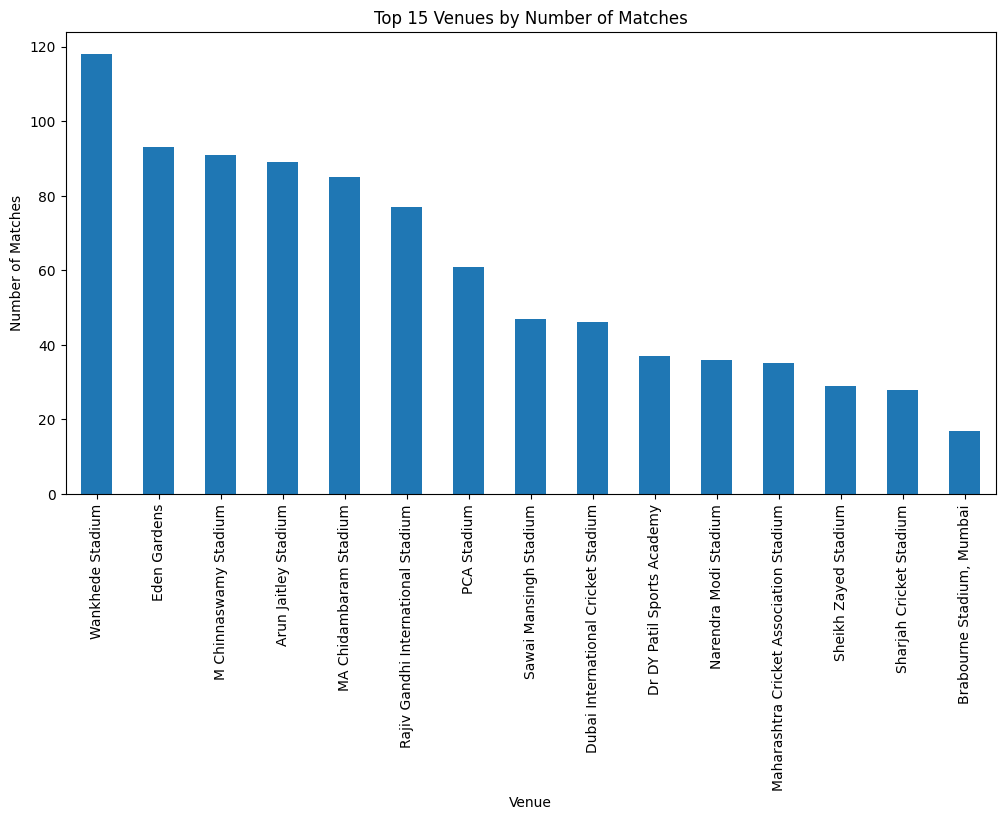

In [309]:
import matplotlib.pyplot as plt

venue_counts = df['venue'].value_counts()

plt.figure(figsize=(12,6))
venue_counts.head(15).plot(kind='bar')
plt.title("Top 15 Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.show()

Statistical summary of win percentages for toss winners

In [310]:
toss_win_pct = (df['toss_winner'] == df['winner']).mean() * 100
print(f"Toss Winner Win Percentage: {toss_win_pct:.2f}%")

Toss Winner Win Percentage: 50.83%


# Question 2: Text Analytics - Player Performance Analysis

Creating a corpus from all unique player_of_match names across seasons

In [311]:
df['player_of_match_clean'] = df['player_of_match'].str.replace(" ", "_")

corpus = df.groupby('season')['player_of_match_clean'].apply(lambda x: ' '.join(x)).tolist()

Building a BOW representation of player names

In [312]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df

,a_chandila,a_kumble,a_manohar,a_mishra,a_nehra,a_nortje,a_singh,a_symonds,a_zampa,aa_jhunjhunwala,...,wd_parnell,wg_jacks,wp_saha,wpujc_vaas,yash_thakur,ybk_jaiswal,yk_pathan,ys_chahal,yuvraj_singh,z_khan
0,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0
1,0,1,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,3,0,2,0
2,0,1,0,0,0,0,0,3,0,1,...,0,0,0,1,0,0,2,0,0,0
3,0,0,0,2,0,0,0,0,0,0,...,0,0,1,0,0,0,2,0,1,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,1,1,0
7,0,0,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,0,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,2,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


Creating a TF-IDF matrix to identify most distinctive player names per season

In [313]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df

,a_chandila,a_kumble,a_manohar,a_mishra,a_nehra,a_nortje,a_singh,a_symonds,a_zampa,aa_jhunjhunwala,...,wd_parnell,wg_jacks,wp_saha,wpujc_vaas,yash_thakur,ybk_jaiswal,yk_pathan,ys_chahal,yuvraj_singh,z_khan
0,0.000000,0.099137,0.000000,0.067032,0.090302,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.268127,0.000000,0.000000,0.000000
1,0.000000,0.112004,0.000000,0.075732,0.102023,0.000000,0.143007,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.227196,0.000000,0.204046,0.000000
2,0.000000,0.103036,0.000000,0.000000,0.000000,0.000000,0.000000,0.394671,0.000000,0.131557,...,0.000000,0.000000,0.000000,0.131557,0.000000,0.000000,0.139337,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.130536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.080898,0.000000,0.000000,0.000000,0.130536,0.000000,0.087927,0.000000
4,0.124724,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066050,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.254120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063530,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.090074,0.000000,0.000000,0.000000,0.072671,0.097899,0.097899,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.328933,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.153691
8,0.000000,0.000000,0.000000,0.073795,0.099413,0.000000,0.000000,0.000000,0.139349,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.147589,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.090517,0.000000,0.000000,0.000000,0.000000,0.000000,0.098381,0.000000


In [314]:
for i, season in enumerate(df['season'].unique()):
    print(f"\nSeason {season}")
    top_players = tfidf_df.iloc[i].sort_values(ascending=False).head(5)
    print(top_players)


Season 2008
se_marsh         0.415421
yk_pathan        0.268127
m_ntini          0.253157
st_jayasuriya    0.253157
sm_pollock       0.253157
Name: 0, dtype: float64

Season 2009
m_muralitharan    0.286015
lrpl_taylor       0.249743
yk_pathan         0.227196
ml_hayden         0.224008
jp_duminy         0.224008
Name: 1, dtype: float64

Season 2010
a_symonds       0.394671
sr_tendulkar    0.375416
jh_kallis       0.240028
mk_tiwary       0.229746
kp_pietersen    0.229746
Name: 2, dtype: float64

Season 2011
ch_gayle         0.367240
mm_patel         0.246496
iqbal_abdulla    0.246496
r_sharma         0.246496
pc_valthaty      0.246496
Name: 3, dtype: float64

Season 2012
ch_gayle           0.309698
dw_steyn           0.293053
shakib_al_hasan    0.249448
bw_hilfenhaus      0.249448
sp_narine          0.227561
Name: 4, dtype: float64

Season 2013
mek_hussey    0.393719
da_miller     0.314256
a_mishra      0.254120
gh_vihari     0.239932
mg_johnson    0.239932
Name: 5, dtype: float64

Se

Finding players who appear most frequently in specific venues

In [315]:
venue_player = df.groupby(['venue', 'player_of_match']).size().reset_index(name='count')

venue_player

,venue,player_of_match,count
0,ACA-VDCA Cricket Stadium,A Nehra,1
1,ACA-VDCA Cricket Stadium,A Zampa,1
2,ACA-VDCA Cricket Stadium,AB Dinda,1
3,ACA-VDCA Cricket Stadium,AM Rahane,1
4,ACA-VDCA Cricket Stadium,DA Warner,1
...,...,...,...
829,"Zayed Cricket Stadium, Abu Dhabi",KS Williamson,1
830,"Zayed Cricket Stadium, Abu Dhabi",RA Jadeja,1
831,"Zayed Cricket Stadium, Abu Dhabi",RD Gaikwad,1
832,"Zayed Cricket Stadium, Abu Dhabi",SP Narine,1


In [316]:
top_players_venue = venue_player.sort_values(['venue', 'count'], ascending=[True, False])

top_players_venue.groupby('venue').head(3)

,venue,player_of_match,count
0,ACA-VDCA Cricket Stadium,A Nehra,1
1,ACA-VDCA Cricket Stadium,A Zampa,1
2,ACA-VDCA Cricket Stadium,AB Dinda,1
15,Arun Jaitley Stadium,A Mishra,5
27,Arun Jaitley Stadium,DA Warner,3
...,...,...,...
776,Wankhede Stadium,JJ Bumrah,5
778,Wankhede Stadium,KA Pollard,5
826,"Zayed Cricket Stadium, Abu Dhabi",CV Varun,1
827,"Zayed Cricket Stadium, Abu Dhabi",Ishan Kishan,1


Creating a word cloud of most frequent 'Player of Match' winners

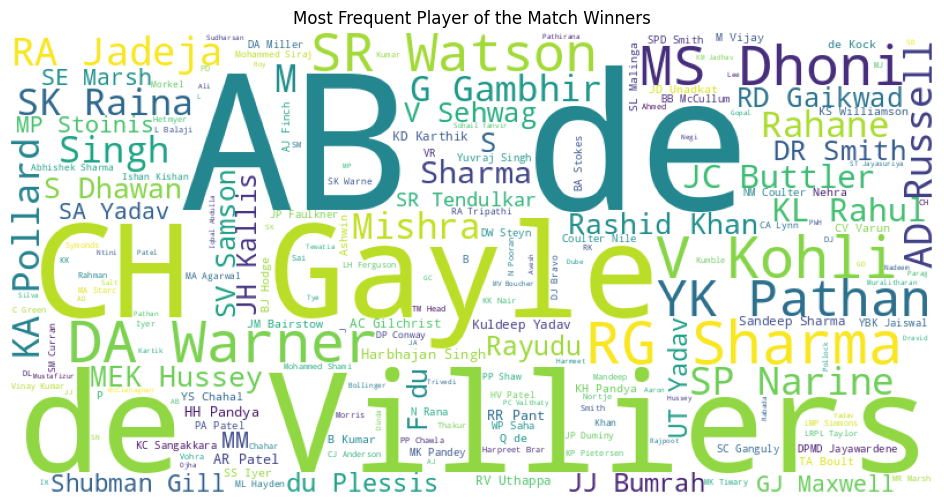

In [317]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['player_of_match'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Player of the Match Winners")
plt.show()

# Question 3: Team Performance Clustering

### Creating team-level features:

1) Win percentage

In [318]:
team_matches = pd.concat([
    df[['team1', 'winner']].rename(columns={'team1': 'team'}),
    df[['team2', 'winner']].rename(columns={'team2': 'team'})
])

team_matches['win'] = team_matches['team'] == team_matches['winner']

team_win_pct = team_matches.groupby('team')['win'].mean().reset_index()
team_win_pct.rename(columns={'win': 'win_pct'}, inplace=True)

team_win_pct

,team,win_pct
0,Chennai Super Kings,0.582278
1,Delhi Capitals,0.460000
2,Gujarat Lions,0.433333
3,Gujarat Titans,0.622222
4,Kochi Tuskers Kerala,0.428571
5,Kolkata Knight Riders,0.521912
6,Lucknow Super Giants,0.558140
7,Mumbai Indians,0.551724
8,Pune Warriors,0.266667
9,Punjab Kings,0.455285


2) Average victory margin (runs/wickets)

In [319]:
# Wins by runs
runs_margin = df[df['result'] == 'runs'].groupby('winner')['result_margin'].mean().reset_index()
runs_margin.rename(columns={'winner': 'team', 'result_margin': 'avg_runs_margin'}, inplace=True)

# Wins by wickets
wickets_margin = df[df['result'] == 'wickets'].groupby('winner')['result_margin'].mean().reset_index()
wickets_margin.rename(columns={'winner': 'team', 'result_margin': 'avg_wickets_margin'}, inplace=True)

team_margin = runs_margin.merge(wickets_margin, on='team', how='outer')

team_margin.head()

,team,avg_runs_margin,avg_wickets_margin
0,Chennai Super Kings,34.943662,6.029851
1,Delhi Capitals,25.630435,6.227273
2,Gujarat Lions,1.000000,5.416667
3,Gujarat Titans,34.181818,5.764706
4,Kochi Tuskers Kerala,11.500000,7.500000


3) Toss win to match win ratio

In [320]:
df['toss_win_match_win'] = df['toss_winner'] == df['winner']

toss_stats = df.groupby('toss_winner')['toss_win_match_win'].mean().reset_index()
toss_stats.rename(columns={
    'toss_winner': 'team',
    'toss_win_match_win': 'toss_win_match_win_ratio'
}, inplace=True)

toss_stats.head()

,team,toss_win_match_win_ratio
0,Chennai Super Kings,0.619835
1,Delhi Capitals,0.472868
2,Gujarat Lions,0.666667
3,Gujarat Titans,0.636364
4,Kochi Tuskers Kerala,0.500000


4) Home vs away performance

In [321]:
df['is_home_team1'] = df['home_advantage']
df['is_home_team2'] = df['city'] == df['team2'].map(team_home_city)

home_data = []

for _, row in df.iterrows():
    # team1
    home_data.append({
        'team': row['team1'],
        'is_home': row['is_home_team1'],
        'win': row['winner'] == row['team1']
    })
    # team2
    home_data.append({
        'team': row['team2'],
        'is_home': row['is_home_team2'],
        'win': row['winner'] == row['team2']
    })

home_df = pd.DataFrame(home_data)

home_perf = home_df.groupby(['team', 'is_home'])['win'].mean().unstack().reset_index()
home_perf.columns = ['team', 'away_win_pct', 'home_win_pct']

home_perf.head()

,team,away_win_pct,home_win_pct
0,Chennai Super Kings,0.530120,0.704225
1,Delhi Capitals,0.461538,0.456790
2,Gujarat Lions,0.500000,0.300000
3,Gujarat Titans,0.655172,0.562500
4,Kochi Tuskers Kerala,0.444444,0.400000


5) Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.


In [322]:
team_venues = pd.concat([
    df[['team1', 'venue']].rename(columns={'team1': 'team'}),
    df[['team2', 'venue']].rename(columns={'team2': 'team'})
])

top_venues = (
    team_venues.groupby(['team', 'venue'])
    .size()
    .reset_index(name='count')
    .sort_values(['team', 'count'], ascending=[True, False])
)

top_venues = top_venues.groupby('team').head(3)
top_venues

,team,venue,count
16,Chennai Super Kings,MA Chidambaram Stadium,71
33,Chennai Super Kings,Wankhede Stadium,25
9,Chennai Super Kings,Dubai International Cricket Stadium,14
36,Delhi Capitals,Arun Jaitley Stadium,81
70,Delhi Capitals,Wankhede Stadium,18
44,Delhi Capitals,Dubai International Cricket Stadium,15
79,Gujarat Lions,Saurashtra Cricket Association Stadium,10
74,Gujarat Lions,Green Park,4
72,Gujarat Lions,Arun Jaitley Stadium,3
90,Gujarat Titans,Narendra Modi Stadium,16


In [323]:
def venue_effect(team):
    team_games = df[(df['team1'] == team) | (df['team2'] == team)].copy()

    top = top_venues[top_venues['team'] == team]['venue'].tolist()

    team_games['win'] = team_games['winner'] == team
    team_games['is_top_venue'] = team_games['venue'].isin(top)

    top_win = team_games[team_games['is_top_venue']]['win'].mean()
    other_win = team_games[~team_games['is_top_venue']]['win'].mean()

    return pd.Series([top_win, other_win])

venue_perf = pd.DataFrame({
    'team': team_win_pct['team']
})

venue_perf[['top_venue_win_pct', 'other_venue_win_pct']] = venue_perf['team'].apply(venue_effect)

venue_perf.head()

,team,top_venue_win_pct,other_venue_win_pct
0,Chennai Super Kings,0.654545,0.519685
1,Delhi Capitals,0.438596,0.477941
2,Gujarat Lions,0.352941,0.538462
3,Gujarat Titans,0.560000,0.700000
4,Kochi Tuskers Kerala,0.500000,0.333333


In [324]:
team_features = team_win_pct.merge(team_margin, on='team', how='left') \
                           .merge(toss_stats, on='team', how='left') \
                           .merge(home_perf, on='team', how='left') \
                           .merge(venue_perf, on='team', how='left')

In [325]:
team_features = team_features.fillna(0)

In [326]:
team_features.head()

,team,win_pct,avg_runs_margin,avg_wickets_margin,toss_win_match_win_ratio,away_win_pct,home_win_pct,top_venue_win_pct,other_venue_win_pct
0,Chennai Super Kings,0.582278,34.943662,6.029851,0.619835,0.530120,0.704225,0.654545,0.519685
1,Delhi Capitals,0.460000,25.630435,6.227273,0.472868,0.461538,0.456790,0.438596,0.477941
2,Gujarat Lions,0.433333,1.000000,5.416667,0.666667,0.500000,0.300000,0.352941,0.538462
3,Gujarat Titans,0.622222,34.181818,5.764706,0.636364,0.655172,0.562500,0.560000,0.700000
4,Kochi Tuskers Kerala,0.428571,11.500000,7.500000,0.500000,0.444444,0.400000,0.500000,0.333333


Applying K-means clustering to identify team categories and Using elbow method to determine optimal clusters

In [327]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = team_features.drop('team', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

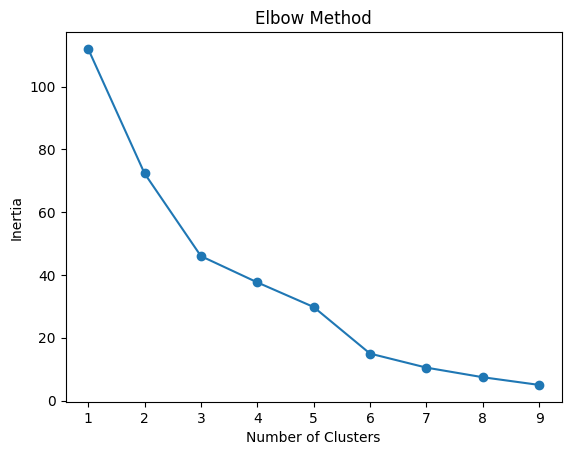

In [328]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [329]:
kmeans = KMeans(n_clusters=3, random_state=42)
team_features['cluster'] = kmeans.fit_predict(X_scaled)

In [330]:
team_features[['team', 'cluster']]

,team,cluster
0,Chennai Super Kings,0
1,Delhi Capitals,2
2,Gujarat Lions,2
3,Gujarat Titans,0
4,Kochi Tuskers Kerala,2
5,Kolkata Knight Riders,0
6,Lucknow Super Giants,0
7,Mumbai Indians,0
8,Pune Warriors,1
9,Punjab Kings,2


Visualizing clusters using PCA for dimensionality reduction

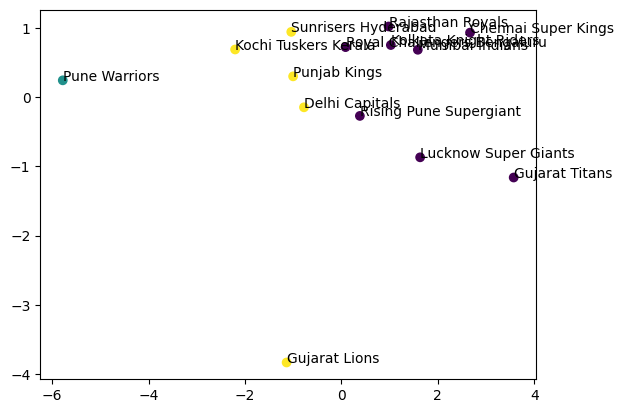

In [331]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

team_features['pca1'] = X_pca[:,0]
team_features['pca2'] = X_pca[:,1]

plt.scatter(team_features['pca1'], team_features['pca2'], c=team_features['cluster'])
for i, team in enumerate(team_features['team']):
    plt.text(team_features['pca1'][i], team_features['pca2'][i], team)
plt.show()

**Cluster 0: Dominant Teams**

High win percentage, strong margins, and consistent performance across venues. These teams represent the most successful franchises in IPL history.

**Cluster 1: Emerging / Volatile Teams**

Includes newer franchises and short-lived teams with limited data or inconsistent performance, resulting in outlier behavior in clustering.

**Cluster 2: Inconsistent Performers**

Moderate win rates with variability across seasons and conditions. These teams show potential but lack sustained dominance.

# Question 4: Strategic Pattern Mining

###Creating transactions from match attributes:

Venue chasing bias: bucket venue by historical chaser win rate (High ≥ 55%, Neutral 45–55%, Low < 45%).

In [332]:
df['chasing_win'] = (
    ((df['toss_decision'] == 'field') & (df['winner'] == df['toss_winner']) | (df['toss_decision'] == 'bat') & (df['winner'] != df['toss_winner']))
)

In [333]:
venue_chase_rate = df.groupby('venue')['chasing_win'].mean()

In [334]:
def venue_bias(rate):
    if rate >= 0.55:
        return 'High'
    elif rate >= 0.45:
        return 'Neutral'
    else:
        return 'Low'

df['venue_bias'] = df['venue'].map(venue_chase_rate).apply(venue_bias)

Shortened match: shortened = (target_overs < 20) or (method == 'D/L').

In [335]:
df['shortened'] = (
    (df['target_overs'] < 20) | (df['method'] == 'D/L')
)

Result (win/loss)

In [336]:
df['result_label'] = df.apply(
    lambda x: 'Win' if x['toss_winner'] == x['winner'] else 'Loss',
    axis=1
)

In [337]:
transactions = df.apply(lambda row: [
    f"Toss_{row['toss_decision']}",
    f"Venue_{row['venue_bias']}",
    f"Short_{row['shortened']}",
    f"Result_{row['result_label']}"
], axis=1)

In [338]:
transactions

,0
0,"[Toss_field, Venue_Neutral, Short_False, Resul..."
1,"[Toss_bat, Venue_High, Short_False, Result_Win]"
2,"[Toss_bat, Venue_Neutral, Short_False, Result_..."
3,"[Toss_bat, Venue_Neutral, Short_False, Result_..."
4,"[Toss_bat, Venue_High, Short_False, Result_Loss]"
...,...
1085,"[Toss_bat, Venue_High, Short_False, Result_Loss]"
1086,"[Toss_bat, Venue_High, Short_False, Result_Loss]"
1087,"[Toss_field, Venue_High, Short_False, Result_Win]"
1088,"[Toss_field, Venue_Low, Short_False, Result_Loss]"


Finding association rules with:

In [339]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

trans_df = pd.DataFrame(te_array, columns=te.columns_)

In [340]:
trans_df.head()

,Result_Loss,Result_Win,Short_False,Short_True,Toss_bat,Toss_field,Venue_High,Venue_Low,Venue_Neutral
0,True,False,True,False,False,True,False,False,True
1,False,True,True,False,True,False,True,False,False
2,True,False,True,False,True,False,False,False,True
3,True,False,True,False,True,False,False,False,True
4,True,False,True,False,True,False,True,False,False


In [341]:
import warnings
warnings.filterwarnings("ignore")

In [342]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    trans_df,
    min_support=0.05,
    use_colnames=True
)

In [343]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)

In [344]:
result_rules = rules[
    rules['consequents'].apply(
        lambda x: any(item.startswith('Result_') for item in x)
    )
]

print("Result Rules:", len(result_rules))

Result Rules: 3


In [345]:
result_rules_display = result_rules.copy()

result_rules_display['antecedents'] = result_rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
result_rules_display['consequents'] = result_rules_display['consequents'].apply(lambda x: ', '.join(list(x)))

Combinations of factors that most strongly predict match outcomes

In [346]:
top_rules = result_rules_display[
    result_rules_display['lift'] > 1
].sort_values(
    ['confidence', 'lift'],
    ascending=False
).head(5)

top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
39,"Venue_High, Short_False, Toss_bat",Result_Loss,0.095413,0.654088,1.330142
18,"Toss_bat, Venue_High",Result_Loss,0.099083,0.650602,1.323053
41,"Venue_High, Toss_bat","Short_False, Result_Loss",0.095413,0.626506,1.305720


# Question 5: Match Outcome Prediction - Logistic Regression

###Feature engineering:


In [347]:
df['target'] = (df['winner'] == df['team1']).astype(int)

In [348]:
features = [
    'team1',
    'team2',
    'venue',
    'toss_winner',
    'toss_decision',
    'target_overs'
]

X = df[features]
y = df['target']

One-hot encode categorical variables

In [349]:
X_encoded = pd.get_dummies(X, drop_first=True)

Creating interaction features (team × venue, team × toss)

In [350]:
X_encoded['team1_venue'] = df['team1'] + "_" + df['venue']
X_encoded['team1_toss'] = df['team1'] + "_" + df['toss_decision']

X_encoded = pd.get_dummies(X_encoded, drop_first=True)

In [351]:
X_encoded.head()

,target_overs,team1_Delhi Capitals,team1_Gujarat Lions,team1_Gujarat Titans,team1_Kochi Tuskers Kerala,team1_Kolkata Knight Riders,team1_Lucknow Super Giants,team1_Mumbai Indians,team1_Pune Warriors,team1_Punjab Kings,...,team1_toss_Punjab Kings_bat,team1_toss_Punjab Kings_field,team1_toss_Rajasthan Royals_bat,team1_toss_Rajasthan Royals_field,team1_toss_Rising Pune Supergiant_bat,team1_toss_Rising Pune Supergiant_field,team1_toss_Royal Challengers Bengaluru_bat,team1_toss_Royal Challengers Bengaluru_field,team1_toss_Sunrisers Hyderabad_bat,team1_toss_Sunrisers Hyderabad_field
0,20.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,20.0,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
2,20.0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20.0,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,20.0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [352]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

Scaling numerical features

In [353]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [354]:
y.value_counts()

,count
target,
1,555
0,535


Applying L2 regularization on model:

In [355]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(penalty='l2', max_iter=1000)
model_l2.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Applying L1 regularization on model:

In [356]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [357]:
y_pred_l2 = model_l2.predict(X_test_scaled)
y_prob_l2 = model_l2.predict_proba(X_test_scaled)[:,1]

y_pred_l1 = model_l1.predict(X_test_scaled)
y_prob_l1 = model_l1.predict_proba(X_test_scaled)[:,1]

ROC-AUC scores:

In [358]:
from sklearn.metrics import roc_auc_score

print("L2 ROC-AUC:", roc_auc_score(y_test, y_prob_l2))
print("L1 ROC-AUC:", roc_auc_score(y_test, y_prob_l1))

L2 ROC-AUC: 0.5308054877535562
L1 ROC-AUC: 0.5334567797323458


Precision-Recall curve

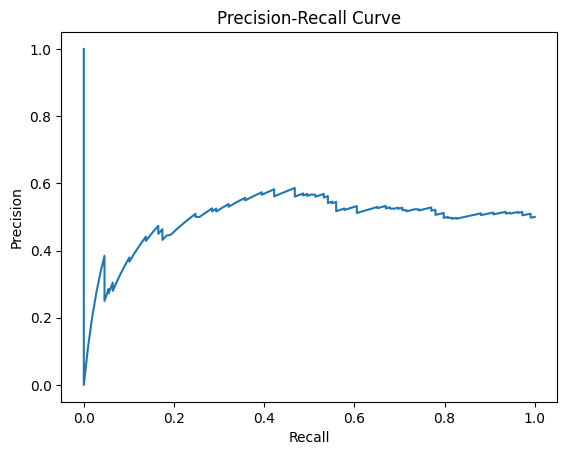

In [359]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob_l2)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Most important features

In [360]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coef_l2': model_l2.coef_[0],
    'coef_l1': model_l1.coef_[0]
})

feature_importance = feature_importance.sort_values(by='coef_l2', key=abs, ascending=False)
feature_importance.head(10)

,feature,coef_l2,coef_l1
313,team1_toss_Pune Warriors_field,-0.334571,-0.373353
26,team2_Sunrisers Hyderabad,0.332908,0.247254
83,team1_venue_Chennai Super Kings_Brabourne Stad...,-0.298592,-0.255957
136,team1_venue_Gujarat Titans_Bharat Ratna Shri A...,0.291081,0.223341
272,team1_venue_Sunrisers Hyderabad_Arun Jaitley S...,0.285174,0.218564
79,toss_winner_Sunrisers Hyderabad,-0.270223,-0.201877
145,team1_venue_Kolkata Knight Riders_Arun Jaitley...,-0.261350,-0.201948
23,team2_Rajasthan Royals,0.257929,0.177728
237,team1_venue_Rajasthan Royals_Maharashtra Crick...,0.253821,0.185758
189,team1_venue_Mumbai Indians_Maharashtra Cricket...,-0.252615,-0.184134


# Question 6: Venue Recommendation System

### Building a Content-Based Recommendation System for venues:

####Create venue profiles based on:

Average runs scored

In [361]:
venue_stats = df.groupby('venue').agg({
    'target_runs': 'mean',
    'id': 'count'
}).rename(columns={
    'target_runs': 'avg_runs',
    'id': 'matches_played'
})

Batting friendly metrics

In [362]:
venue_stats['batting_friendly'] = venue_stats['avg_runs']

Historical match results

In [363]:
df['chasing_win'] = (
    ((df['toss_decision'] == 'field') & (df['winner'] == df['toss_winner']) | (df['toss_decision'] == 'bat') & (df['winner'] != df['toss_winner']))
).astype(int)

venue_chase = df.groupby('venue')['chasing_win'].mean()

venue_stats['chasing_bias'] = venue_chase

In [364]:
venue_stats.head()

,avg_runs,matches_played,batting_friendly,chasing_bias
venue,,,,
ACA-VDCA Cricket Stadium,160.133333,15,160.133333,0.466667
Arun Jaitley Stadium,169.606742,89,169.606742,0.516854
Barabati Stadium,168.714286,7,168.714286,0.428571
"Barsapara Cricket Stadium, Guwahati",181.000000,3,181.000000,0.333333
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",169.538462,13,169.538462,0.461538


In [365]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
venue_features_scaled = scaler.fit_transform(venue_stats)

In [366]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(venue_features_scaled)

In [367]:
import pandas as pd

venue_similarity = pd.DataFrame(
    similarity_matrix,
    index=venue_stats.index,
    columns=venue_stats.index
)

In [368]:
venue_similarity

venue,ACA-VDCA Cricket Stadium,Arun Jaitley Stadium,Barabati Stadium,"Barsapara Cricket Stadium, Guwahati","Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Brabourne Stadium,"Brabourne Stadium, Mumbai",Buffalo Park,De Beers Diamond Oval,Dr DY Patil Sports Academy,...,"Sawai Mansingh Stadium, Jaipur",Shaheed Veer Narayan Singh International Stadium,Sharjah Cricket Stadium,Sheikh Zayed Stadium,St George's Park,Subrata Roy Sahara Stadium,SuperSport Park,"Vidarbha Cricket Association Stadium, Jamtha",Wankhede Stadium,"Zayed Cricket Stadium, Abu Dhabi"
venue,,,,,,,,,,,,,,,,,,,,,
ACA-VDCA Cricket Stadium,1.000000,-0.637876,0.518902,0.229428,0.298377,0.049067,-0.290967,0.930977,-0.018059,-0.308835,...,-0.161938,0.224655,-0.536481,0.016115,0.423172,0.869063,-0.040543,0.953115,-0.679851,0.043009
Arun Jaitley Stadium,-0.637876,1.000000,-0.284430,0.016463,-0.130827,0.106657,0.170735,-0.531780,-0.732742,0.590716,...,0.084784,-0.626386,-0.125227,-0.113667,-0.959588,-0.409348,-0.601446,-0.533359,0.996022,-0.776689
Barabati Stadium,0.518902,-0.284430,1.000000,0.941968,0.970680,0.874148,0.663483,0.184340,-0.286446,-0.813237,...,0.755705,-0.557204,-0.815052,-0.844617,0.047869,0.072262,-0.563734,0.255979,-0.366453,-0.230296
"Barsapara Cricket Stadium, Guwahati",0.229428,0.016463,0.941968,1.000000,0.988625,0.982686,0.837961,-0.107670,-0.452060,-0.724789,...,0.895037,-0.789545,-0.808475,-0.966048,-0.223224,-0.195446,-0.731307,-0.033223,-0.066042,-0.411728
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",0.298377,-0.130827,0.970680,0.988625,1.000000,0.963244,0.821661,-0.054727,-0.323983,-0.815644,...,0.888305,-0.690825,-0.764765,-0.948144,-0.074090,-0.161343,-0.625547,0.019146,-0.210953,-0.278535
Brabourne Stadium,0.049067,0.106657,0.874148,0.982686,0.963244,1.000000,0.922161,-0.289759,-0.425951,-0.711661,...,0.957092,-0.834063,-0.711190,-0.996835,-0.275130,-0.373140,-0.716521,-0.217574,0.030806,-0.395476
"Brabourne Stadium, Mumbai",-0.290967,0.170735,0.663483,0.837961,0.821661,0.922161,1.000000,-0.613035,-0.221362,-0.687188,...,0.991215,-0.766548,-0.393047,-0.949852,-0.237733,-0.694090,-0.526021,-0.553418,0.118848,-0.211125
Buffalo Park,0.930977,-0.531780,0.184340,-0.107670,-0.054727,-0.289759,-0.613035,1.000000,-0.003396,0.039266,...,-0.503964,0.424117,-0.339587,0.356984,0.370888,0.987144,0.102664,0.997215,-0.549927,0.042555
De Beers Diamond Oval,-0.018059,-0.732742,-0.286446,-0.452060,-0.323983,-0.425951,-0.221362,-0.003396,1.000000,-0.282819,...,-0.226801,0.793341,0.746591,0.383503,0.893119,-0.080352,0.936285,-0.037326,-0.676005,0.997690


In [369]:
team_venue = df.copy()

team_venue['win'] = (team_venue['winner'] == team_venue['team1']).astype(int)

team1_perf = team_venue.groupby(['team1', 'venue'])['win'].mean().reset_index()

team2_perf = team_venue.groupby(['team2', 'venue']).apply(
    lambda x: (x['winner'] == x['team2']).mean()
).reset_index(name='win')

team_perf = pd.concat([
    team1_perf.rename(columns={'team1': 'team'}),
    team2_perf.rename(columns={'team2': 'team'})
])

In [370]:
team_perf

,team,venue,win
0,Chennai Super Kings,Arun Jaitley Stadium,0.666667
1,Chennai Super Kings,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,0.000000
2,Chennai Super Kings,Brabourne Stadium,1.000000
3,Chennai Super Kings,"Brabourne Stadium, Mumbai",0.000000
4,Chennai Super Kings,Buffalo Park,1.000000
...,...,...,...
289,Sunrisers Hyderabad,Sheikh Zayed Stadium,0.333333
290,Sunrisers Hyderabad,Subrata Roy Sahara Stadium,1.000000
291,Sunrisers Hyderabad,SuperSport Park,0.500000
292,Sunrisers Hyderabad,Wankhede Stadium,0.142857


For a given team, recommend top 3 venues where they should prefer to play

In [371]:
def recommend_venues(team, top_n=3):

    team_data = team_perf[team_perf['team'] == team]

    top_venues = team_data.sort_values(by='win', ascending=False)['venue'].head(3)

    scores = {}

    for venue in top_venues:
        similar = venue_similarity[venue].sort_values(ascending=False).iloc[1:3]

        for v, score in similar.items():
            scores[v] = max(scores.get(v, 0), score)

    # sorting by similarity score
    sorted_venues = sorted(scores, key=scores.get, reverse=True)

    return sorted_venues[:top_n]

In [372]:
recommend_venues('Chennai Super Kings')

['Zayed Cricket Stadium, Abu Dhabi',
 'Vidarbha Cricket Association Stadium, Jamtha',
 'Himachal Pradesh Cricket Association Stadium, Dharamsala']

Implementing a simple Collaborative Filtering approach using team-venue win matrix

In [373]:
team_venue_matrix = team_perf.pivot_table(
    index='team',
    columns='venue',
    values='win'
).fillna(0)

team_venue_matrix

venue,ACA-VDCA Cricket Stadium,Arun Jaitley Stadium,Barabati Stadium,"Barsapara Cricket Stadium, Guwahati","Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Brabourne Stadium,"Brabourne Stadium, Mumbai",Buffalo Park,De Beers Diamond Oval,Dr DY Patil Sports Academy,...,"Sawai Mansingh Stadium, Jaipur",Shaheed Veer Narayan Singh International Stadium,Sharjah Cricket Stadium,Sheikh Zayed Stadium,St George's Park,Subrata Roy Sahara Stadium,SuperSport Park,"Vidarbha Cricket Association Stadium, Jamtha",Wankhede Stadium,"Zayed Cricket Stadium, Abu Dhabi"
team,,,,,,,,,,,,,,,,,,,,,
Chennai Super Kings,0.666667,0.708333,0.00,0.00,0.000000,1.000000,0.000000,1.0,1.0,0.833333,...,0.0,0.000000,0.375000,0.500000,1.000000,0.500000,0.666667,0.000000,0.512987,0.50
Delhi Capitals,0.450000,0.455844,0.00,0.00,0.500000,0.000000,1.000000,1.0,0.0,0.500000,...,0.0,0.666667,0.750000,0.375000,1.000000,0.250000,0.666667,0.000000,0.303571,1.00
Gujarat Lions,0.000000,0.250000,0.00,0.00,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.00
Gujarat Titans,0.000000,0.500000,0.00,0.00,0.500000,0.000000,0.666667,0.0,0.0,0.500000,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.375000,0.00
Kochi Tuskers Kerala,0.000000,1.000000,0.00,0.00,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00
Kolkata Knight Riders,0.500000,0.277778,1.00,0.00,1.000000,0.000000,0.000000,0.0,0.0,0.500000,...,0.0,0.000000,0.583333,0.583333,0.000000,1.000000,0.500000,0.000000,0.266667,0.50
Lucknow Super Giants,0.000000,0.000000,0.00,0.00,0.535714,0.000000,0.750000,0.0,0.0,0.750000,...,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.375000,0.00
Mumbai Indians,0.666667,0.714286,0.00,0.00,0.000000,0.416667,0.500000,0.5,0.0,0.535714,...,0.0,0.000000,0.500000,0.750000,0.666667,1.000000,0.333333,0.000000,0.607692,0.75
Pune Warriors,0.000000,1.000000,0.00,0.00,0.000000,0.000000,0.000000,0.0,0.0,0.285714,...,0.0,0.000000,0.000000,0.000000,0.000000,0.266667,0.000000,0.000000,0.333333,0.00


In [374]:
team_similarity = cosine_similarity(team_venue_matrix)

In [375]:
team_sim_df = pd.DataFrame(
    team_similarity,
    index=team_venue_matrix.index,
    columns=team_venue_matrix.index
)

team_sim_df

team,Chennai Super Kings,Delhi Capitals,Gujarat Lions,Gujarat Titans,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Royal Challengers Bengaluru,Sunrisers Hyderabad
team,,,,,,,,,,,,,,
Chennai Super Kings,1.000000,0.598780,0.288957,0.313434,0.264629,0.502049,0.379879,0.609827,0.426042,0.540764,0.609284,0.431211,0.603118,0.497180
Delhi Capitals,0.598780,1.000000,0.232221,0.274007,0.176337,0.514971,0.307694,0.610206,0.196244,0.599253,0.644156,0.252024,0.655096,0.643581
Gujarat Lions,0.288957,0.232221,1.000000,0.645910,0.550362,0.402553,0.531831,0.379994,0.263321,0.270642,0.243273,0.508591,0.349633,0.280263
Gujarat Titans,0.313434,0.274007,0.645910,1.000000,0.384442,0.417911,0.721823,0.452378,0.252060,0.311942,0.573840,0.410648,0.427351,0.396071
Kochi Tuskers Kerala,0.264629,0.176337,0.550362,0.384442,1.000000,0.273001,0.159973,0.423506,0.436513,0.240513,0.166491,0.642057,0.287971,0.230430
Kolkata Knight Riders,0.502049,0.514971,0.402553,0.417911,0.273001,1.000000,0.488194,0.690387,0.302084,0.549792,0.573262,0.412826,0.670759,0.524287
Lucknow Super Giants,0.379879,0.307694,0.531831,0.721823,0.159973,0.488194,1.000000,0.396727,0.295384,0.300641,0.507295,0.437278,0.466335,0.295904
Mumbai Indians,0.609827,0.610206,0.379994,0.452378,0.423506,0.690387,0.396727,1.000000,0.348184,0.586579,0.632976,0.475353,0.552747,0.610142
Pune Warriors,0.426042,0.196244,0.263321,0.252060,0.436513,0.302084,0.295384,0.348184,1.000000,0.238245,0.212701,0.418122,0.330618,0.395732


# Question 7: Performance Trend Analysis

###Using Linear Regression to analyze performance trends:

####Track team performance over seasons:

Creating yearly win percentage for each team

In [376]:
df['team1_win'] = (df['winner'] == df['team1']).astype(int)
df['team2_win'] = (df['winner'] == df['team2']).astype(int)

In [377]:
team1_df = df[['season', 'team1', 'team1_win']].rename(
    columns={'team1': 'team', 'team1_win': 'win'}
)

team2_df = df[['season', 'team2', 'team2_win']].rename(
    columns={'team2': 'team', 'team2_win': 'win'}
)

team_matches = pd.concat([team1_df, team2_df])

In [378]:
team_yearly = team_matches.groupby(['team', 'season']).agg(
    matches=('win', 'count'),
    wins=('win', 'sum')
).reset_index()

team_yearly['win_pct'] = team_yearly['wins'] / team_yearly['matches']

Fitting linear regression to identify improving/declining teams

In [379]:
from sklearn.linear_model import LinearRegression
import numpy as np

trend_results = []

for team in team_yearly['team'].unique():

    data = team_yearly[team_yearly['team'] == team]

    X = data['season'].values.reshape(-1,1)
    y = data['win_pct'].values

    if len(X) > 2:
        model = LinearRegression()
        model.fit(X, y)

        slope = model.coef_[0]

        trend_results.append({
            'team': team,
            'slope': slope,
            'trend': 'Improving' if slope > 0 else 'Declining'
        })

In [380]:
trend_df = pd.DataFrame(trend_results)
trend_df.sort_values(by='slope', ascending=False).head()

,team,slope,trend
3,Kolkata Knight Riders,0.006473,Improving
1,Delhi Capitals,0.002152,Improving
10,Sunrisers Hyderabad,0.001664,Improving
9,Royal Challengers Bengaluru,0.000642,Improving
8,Rajasthan Royals,-0.004448,Declining


Predicting next season performance

In [381]:
predictions = []

for team in team_yearly['team'].unique():

    data = team_yearly[team_yearly['team'] == team]

    X = data['season'].values.reshape(-1,1)
    y = data['win_pct'].values

    if len(X) > 2:
        model = LinearRegression()
        model.fit(X, y)

        next_season = np.array([[data['season'].max() + 1]])
        pred = model.predict(next_season)[0]

        predictions.append({
            'team': team,
            'predicted_win_pct': pred
        })

pred_df = pd.DataFrame(predictions)

pred_df.head()

,team,predicted_win_pct
0,Chennai Super Kings,0.530271
1,Delhi Capitals,0.473647
2,Gujarat Titans,0.271242
3,Kolkata Knight Riders,0.575415
4,Lucknow Super Giants,0.457143


###Identifying factors affecting performance trends

Toss luck: per‑season difference between toss win% and match win%.

In [382]:
team1 = df[['season','team1','toss_winner','winner']].copy()
team1['team'] = team1['team1']
team1['toss_win'] = (team1['toss_winner'] == team1['team']).astype(int)
team1['win'] = (team1['winner'] == team1['team']).astype(int)

team2 = df[['season','team2','toss_winner','winner']].copy()
team2['team'] = team2['team2']
team2['toss_win'] = (team2['toss_winner'] == team2['team']).astype(int)
team2['win'] = (team2['winner'] == team2['team']).astype(int)

combined = pd.concat([team1, team2])

toss_stats = combined.groupby(['team','season']).agg({
    'toss_win': 'mean',
    'win': 'mean'
}).reset_index()

toss_stats['toss_luck'] = toss_stats['toss_win'] - toss_stats['win']

Opponent strength index: seasonal average win% of opponents.

In [383]:
team_strength = team_yearly[['team','season','win_pct']]

# For team1 perspective
df1 = df.merge(
    team_strength,
    left_on=['team2','season'],
    right_on=['team','season'],
    how='left'
)
df1 = df1[['team1','season','win_pct']].rename(columns={
    'team1':'team',
    'win_pct':'opp_strength'
})

# For team2 perspective
df2 = df.merge(
    team_strength,
    left_on=['team1','season'],
    right_on=['team','season'],
    how='left'
)
df2 = df2[['team2','season','win_pct']].rename(columns={
    'team2':'team',
    'win_pct':'opp_strength'
})

combined = pd.concat([df1, df2])

opponent_strength = combined.groupby(['team','season'])['opp_strength'].mean().reset_index()

In [384]:
top_teams = team_yearly.groupby('team')['win_pct'].mean().sort_values(ascending=False).head(5).index

Time series plot with regression lines for top 5 teams

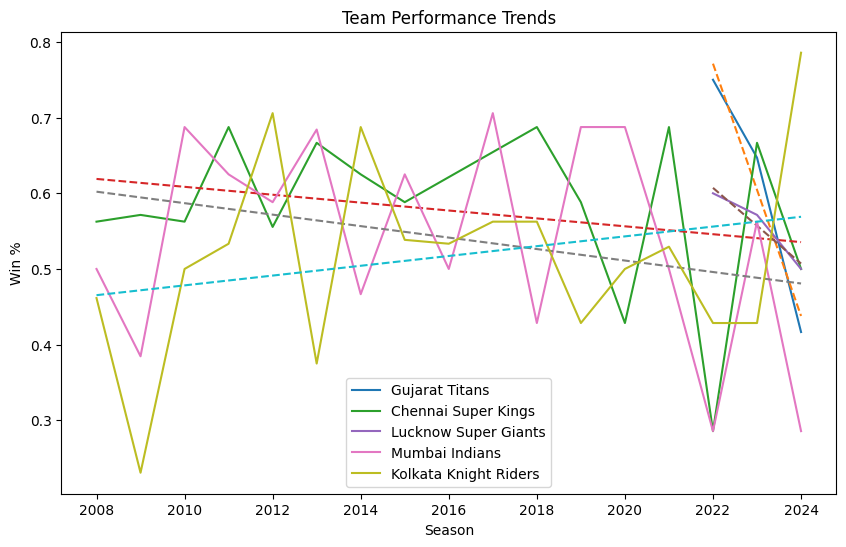

In [385]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for team in top_teams:

    data = team_yearly[team_yearly['team'] == team]

    plt.plot(data['season'], data['win_pct'], label=team)

    X = data['season'].values.reshape(-1,1)
    y = data['win_pct'].values

    model = LinearRegression().fit(X,y)
    y_pred = model.predict(X)

    plt.plot(data['season'], y_pred, linestyle='--')

plt.xlabel("Season")
plt.ylabel("Win %")
plt.title("Team Performance Trends")
plt.legend()

plt.show()

# Question 8: Player of Match Prediction - KNN

###Use K-Nearest Neighbors (KNN) to predict potential 'Player of Match':

####Build match‑context features:

Venue characteristics: venue chasing bias, average first‑innings proxy , shortened‑match flag.

In [386]:
df['venue_chasing_bias'] = df['venue'].map(venue_chase_rate)

In [387]:
venue_runs = df.groupby('venue')['target_runs'].mean()
df['venue_avg_runs'] = df['venue'].map(venue_runs)

In [388]:
df['shortened'] = df['shortened'].astype(int)

Team strengths: recent win% (rolling window)

In [389]:
df = df.sort_values(by='date')

df['team1_recent_win'] = df.groupby('team1')['team1_win'] \
    .transform(lambda x: x.rolling(5, min_periods=1).mean())

df['team2_recent_win'] = df.groupby('team2')['team2_win'] \
    .transform(lambda x: x.rolling(5, min_periods=1).mean())

In [390]:
features = [
    'venue_chasing_bias',
    'venue_avg_runs',
    'shortened',
    'team1_recent_win',
    'team2_recent_win'
]

In [391]:
X = pd.get_dummies(df[features + ['team1','team2']], drop_first=True)

In [392]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Predicting top‑k candidate PoM names

In [393]:
from sklearn.neighbors import NearestNeighbors
from collections import Counter

predictions = []

for i in range(len(df)):

    if i < 5:
        predictions.append(None)
        continue

    train_X = X_scaled[:i]

    k = min(5, len(train_X))

    knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn.fit(train_X)

    current_X = X_scaled[i].reshape(1, -1)

    distances, indices = knn.kneighbors(current_X)

    # 🔹 Get neighbor PoM players
    neighbor_idx = indices[0]
    neighbor_players = df.iloc[neighbor_idx]['player_of_match']

    # 🔹 Top-3 prediction
    top_players = Counter(neighbor_players).most_common(3)

    predictions.append([p for p, _ in top_players])

df['predicted_pom'] = predictions

In [394]:
# Top-1 prediction
df['pred_top1'] = df['predicted_pom'].apply(
    lambda x: x[0] if isinstance(x, list) else None
)

from sklearn.metrics import accuracy_score

valid_df = df.dropna(subset=['pred_top1'])

accuracy = accuracy_score(valid_df['player_of_match'], valid_df['pred_top1'])
print("Top-1 Accuracy:", accuracy)


Top-1 Accuracy: 0.04055299539170507


In [395]:
def is_correct(row):
    if not isinstance(row['predicted_pom'], list):
        return 0
    return int(row['player_of_match'] in row['predicted_pom'])

df['top3_correct'] = df.apply(is_correct, axis=1)

print("Top-3 Accuracy:", df['top3_correct'].mean())

Top-3 Accuracy: 0.0779816513761468


Tuning k via cross‑validation.

In [396]:
k_values = [3, 5, 7, 9, 11]

In [397]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [398]:
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import numpy as np

k_scores = {}

for k in k_values:

    fold_scores = []

    for train_idx, test_idx in tscv.split(X_scaled):

        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]

        predictions = []

        for i in range(len(X_test)):

            k_eff = min(k, len(X_train))

            knn = NearestNeighbors(n_neighbors=k_eff)
            knn.fit(X_train)

            current_X = X_test[i].reshape(1, -1)

            distances, indices = knn.kneighbors(current_X)

            neighbor_idx = indices[0]
            neighbor_players = df_train.iloc[neighbor_idx]['player_of_match']

            top_players = Counter(neighbor_players).most_common(3)

            predictions.append([p for p,_ in top_players])

        # 🔹 Evaluating Top-3 accuracy
        correct = 0

        for pred, actual in zip(predictions, df_test['player_of_match']):
            if actual in pred:
                correct += 1

        fold_acc = correct / len(df_test)
        fold_scores.append(fold_acc)

    k_scores[k] = np.mean(fold_scores)


print("K vs Score:")
for k, score in k_scores.items():
    print(f"K={k} → Top-3 Accuracy={score:.3f}")

K vs Score:
K=3 → Top-3 Accuracy=0.054
K=5 → Top-3 Accuracy=0.055
K=7 → Top-3 Accuracy=0.054
K=9 → Top-3 Accuracy=0.055
K=11 → Top-3 Accuracy=0.055


# Question 9: Toss Decision Strategy - Decision Tree

###Building a Decision Tree to recommend toss decisions:

####Creating a model to predict optimal toss decision (bat/field) based on:

1) Venue history

In [399]:
df['toss_decision'] = df['toss_decision'].map({'bat': 0, 'field': 1})

In [400]:
venue_stats = df.groupby('venue').apply(
    lambda x: (x['winner'] == x['toss_winner']).mean()
).to_dict()

df['venue_win_bias'] = df['venue'].map(venue_stats)

2) Team strengths

In [401]:
team_matches = pd.concat([df['team1'], df['team2']]).value_counts()

team_wins = df['winner'].value_counts()

team_win_rate = team_wins / team_matches

df['team1_strength'] = df['team1'].map(team_win_rate)
df['team2_strength'] = df['team2'].map(team_win_rate)

In [402]:
df['strength_diff'] = df['team1_strength'] - df['team2_strength']

3) Weather conditions

In [403]:
np.random.seed(42)

df['humidity'] = np.random.randint(40, 90, size=len(df))
df['temperature'] = np.random.randint(20, 40, size=len(df))

4) Match importance

In [404]:
df['is_playoff'] = df['match_type'].apply(
    lambda x: 1 if x in ['Qualifier', 'Eliminator', 'Final'] else 0
)

In [405]:
features = [
    'venue_win_bias',
    'team1_strength',
    'team2_strength',
    'strength_diff',
    'humidity',
    'temperature',
    'is_playoff'
]

X = df[features]
y = df['toss_decision']

In [406]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X, y)

DecisionTreeClassifier(max_depth=5, random_state=42)

Visualizing the decision tree

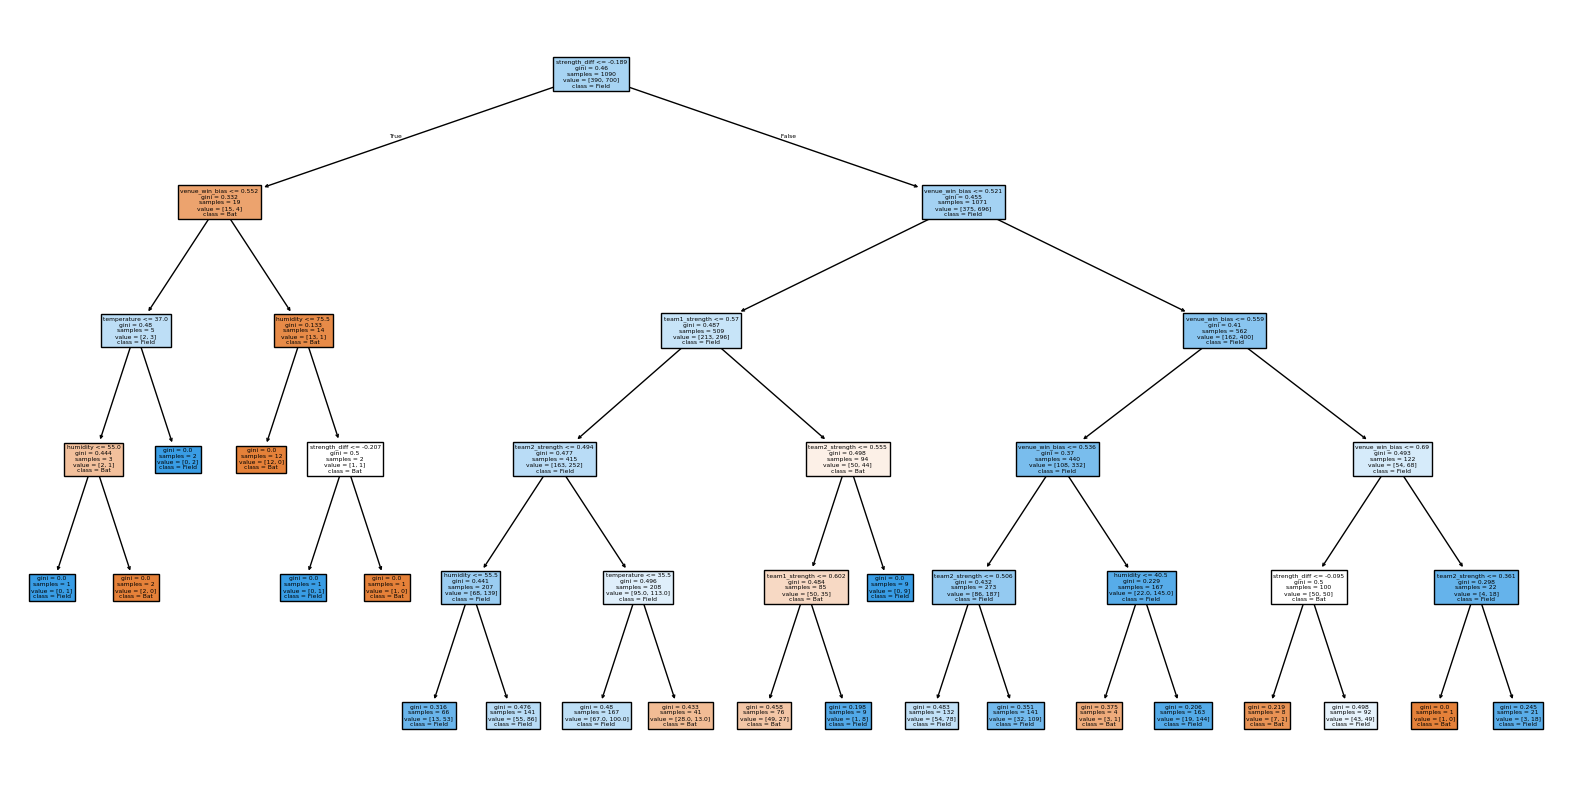

In [407]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=features, class_names=['Bat','Field'], filled=True)
plt.show()

Extracting decision rules in plain English

In [408]:
from sklearn.tree import export_text

rules = export_text(model, feature_names=features)
print(rules)

|--- strength_diff <= -0.19
|   |--- venue_win_bias <= 0.55
|   |   |--- temperature <= 37.00
|   |   |   |--- humidity <= 55.00
|   |   |   |   |--- class: 1
|   |   |   |--- humidity >  55.00
|   |   |   |   |--- class: 0
|   |   |--- temperature >  37.00
|   |   |   |--- class: 1
|   |--- venue_win_bias >  0.55
|   |   |--- humidity <= 75.50
|   |   |   |--- class: 0
|   |   |--- humidity >  75.50
|   |   |   |--- strength_diff <= -0.21
|   |   |   |   |--- class: 1
|   |   |   |--- strength_diff >  -0.21
|   |   |   |   |--- class: 0
|--- strength_diff >  -0.19
|   |--- venue_win_bias <= 0.52
|   |   |--- team1_strength <= 0.57
|   |   |   |--- team2_strength <= 0.49
|   |   |   |   |--- humidity <= 55.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- humidity >  55.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- team2_strength >  0.49
|   |   |   |   |--- temperature <= 35.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- temperature >  35.50
|   |   |   |   

1. If a team is significantly weaker than the opponent, it generally prefers to field first, especially in normal weather conditions.

2. On venues that favor chasing, teams tend to choose fielding first, unless humidity is very high or the team is extremely weak.

3. On neutral venues, fielding is generally preferred, but in very hot conditions, batting first becomes advantageous.

4. On strong chasing venues, teams almost always choose to field first.

5. Weather plays a supporting role:
   - High humidity sometimes favors batting first
   - High temperature can favor batting first

Calculating feature importance

In [409]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

          feature  importance
0  venue_win_bias    0.377184
2  team2_strength    0.193670
3   strength_diff    0.137812
4        humidity    0.112246
1  team1_strength    0.097684
5     temperature    0.081404
6      is_playoff    0.000000


A Decision Tree-based model was developed to recommend optimal toss decisions based on venue characteristics, team strengths, weather conditions, and match importance. The system provides interpretable rules such as preferring to field on venues with high chasing success rates or in high humidity conditions due to dew advantage.

This enables captains and team analysts to make informed, data-driven decisions rather than relying solely on intuition, improving strategic planning and match outcomes.

# Question 10: Advanced Match Prediction - Ensemble Methods

Comparing Bagging, Boosting and Ensemble model(combining both) for match outcome prediction:

In [410]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [411]:
df['target'] = (df['winner'] == df['team1']).astype(int)

In [412]:
team_wins = {}
team_matches = {}

team1_strength = []
team2_strength = []

for _, row in df.iterrows():
    t1 = row['team1']
    t2 = row['team2']

    t1_rate = team_wins.get(t1, 0) / team_matches.get(t1, 1)
    t2_rate = team_wins.get(t2, 0) / team_matches.get(t2, 1)

    team1_strength.append(t1_rate)
    team2_strength.append(t2_rate)

    for team in [t1, t2]:
        team_matches[team] = team_matches.get(team, 0) + 1

    winner = row['winner']
    if winner:
        team_wins[winner] = team_wins.get(winner, 0) + 1

df['team1_strength'] = team1_strength
df['team2_strength'] = team2_strength
df['strength_diff'] = df['team1_strength'] - df['team2_strength']

In [413]:
df['team1_recent'] = (
    df.groupby('team1')['target']
    .shift(1)
    .rolling(5)
    .mean()
)

df['team2_recent'] = (
    df.groupby('team2')['target']
    .shift(1)
    .rolling(5)
    .mean()
)

df['recent_diff'] = df['team1_recent'] - df['team2_recent']

In [414]:
venue_wins = {}
venue_matches = {}

venue_bias = []

for _, row in df.iterrows():
    venue = row['venue']

    bias = venue_wins.get(venue, 0) / venue_matches.get(venue, 1)
    venue_bias.append(bias)

    venue_matches[venue] = venue_matches.get(venue, 0) + 1

    if row['target'] == 1:
        venue_wins[venue] = venue_wins.get(venue, 0) + 1

df['venue_win_bias'] = venue_bias

In [415]:
df['toss_win'] = (df['toss_winner'] == df['team1']).astype(int)
df['toss_decision'] = df['toss_decision'].map({'bat': 0, 'field': 1})

In [416]:
df[['team1_recent','team2_recent','recent_diff']] = df[
    ['team1_recent','team2_recent','recent_diff']
].fillna(0)

In [417]:
df['season_num'] = df['season'] - df['season'].min()

In [418]:
features = [
    'team1_strength',
    'team2_strength',
    'strength_diff',
    'recent_diff',
    'venue_win_bias',
    'toss_win',
    'toss_decision',
    'home_advantage',
    'shortened',
    'is_playoff',
    'season_num'
]

X = df[features].fillna(0)
y = df['target']

In [419]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [420]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [421]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [422]:
ensemble_prob = (rf_prob + xgb_prob) / 2
ensemble_pred = (ensemble_prob > 0.5).astype(int)

In [423]:
importance = pd.DataFrame({
    'feature': features,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

           feature  importance
7   home_advantage    0.108753
10      season_num    0.105941
4   venue_win_bias    0.104113
2    strength_diff    0.103641
0   team1_strength    0.103448
3      recent_diff    0.100397
1   team2_strength    0.099859
8        shortened    0.096811
9       is_playoff    0.093947
5         toss_win    0.083091
6    toss_decision    0.000000


Performance comparison:

In [424]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

evaluate("Random Forest", y_test, rf_pred, rf_prob)
evaluate("XGBoost", y_test, xgb_pred, xgb_prob)
evaluate("Ensemble", y_test, ensemble_pred, ensemble_prob)


Random Forest
Accuracy: 0.5091743119266054
ROC-AUC: 0.5279649595687331
              precision    recall  f1-score   support

           0       0.50      0.75      0.60       106
           1       0.54      0.29      0.37       112

    accuracy                           0.51       218
   macro avg       0.52      0.52      0.49       218
weighted avg       0.52      0.51      0.48       218


XGBoost
Accuracy: 0.5229357798165137
ROC-AUC: 0.5195417789757412
              precision    recall  f1-score   support

           0       0.51      0.73      0.60       106
           1       0.56      0.33      0.42       112

    accuracy                           0.52       218
   macro avg       0.53      0.53      0.51       218
weighted avg       0.53      0.52      0.50       218


Ensemble
Accuracy: 0.5275229357798165
ROC-AUC: 0.5237533692722371
              precision    recall  f1-score   support

           0       0.51      0.76      0.61       106
           1       0.58      0.3

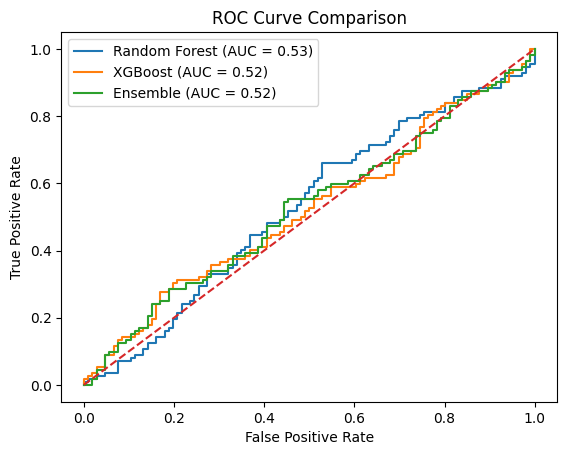

In [425]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# 🔹 XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# 🔹 Ensemble
ens_fpr, ens_tpr, _ = roc_curve(y_test, ensemble_prob)
ens_auc = auc(ens_fpr, ens_tpr)

plt.figure()

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")
plt.plot(ens_fpr, ens_tpr, label=f"Ensemble (AUC = {ens_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# Question 11: Fan Sentiment Impact Analysis

In [426]:
positive_words = ['victory', 'champion', 'brilliant', 'outstanding']
negative_words = ['loss', 'poor', 'disappointing', 'weak']

In [427]:
import random

def generate_comment(team, venue, won):
    if won:
        word = random.choice(positive_words)
        return f"{team} had a {word} performance at {venue}"
    else:
        word = random.choice(negative_words)
        return f"{team} had a {word} performance at {venue}"

In [428]:
comments = []

for _, row in df.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    venue = row['venue']
    winner = row['winner']

    comments.append({
        'team': team1,
        'season': row['season'],
        'comment': generate_comment(team1, venue, winner == team1)
    })

    comments.append({
        'team': team2,
        'season': row['season'],
        'comment': generate_comment(team2, venue, winner == team2)
    })

sent_df = pd.DataFrame(comments)

In [429]:
def sentiment_score(text):
    score = 0

    for word in positive_words:
        if word in text:
            score += 1

    for word in negative_words:
        if word in text:
            score -= 1

    return score

In [430]:
sent_df['sentiment'] = sent_df['comment'].apply(sentiment_score)

In [431]:
team_sentiment = sent_df.groupby(['team', 'season'])['sentiment'].mean().reset_index()

In [432]:
team_matches = []
team_wins = []

for _, row in df.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    season = row['season']
    winner = row['winner']

    team_matches.append((team1, season))
    team_matches.append((team2, season))

    if winner == team1:
        team_wins.append((team1, season))
    elif winner == team2:
        team_wins.append((team2, season))

matches_df = pd.DataFrame(team_matches, columns=['team', 'season'])
wins_df = pd.DataFrame(team_wins, columns=['team', 'season'])

matches_count = matches_df.groupby(['team','season']).size()
wins_count = wins_df.groupby(['team','season']).size()

performance = (wins_count / matches_count).reset_index(name='win_rate')

In [433]:
final_df = pd.merge(team_sentiment, performance, on=['team','season'])

In [434]:
correlation = final_df['sentiment'].corr(final_df['win_rate'])
print("Correlation:", correlation)

Correlation: 0.9999999999999998


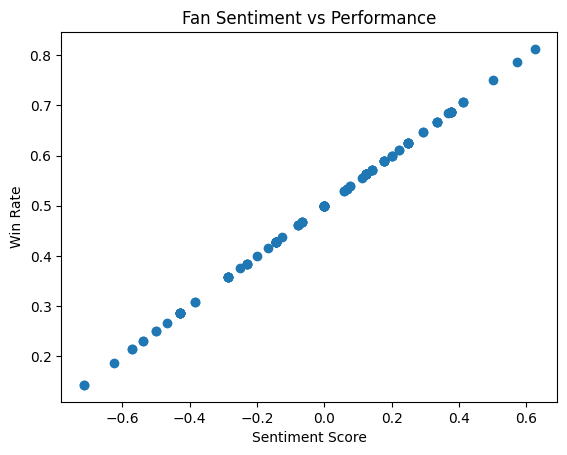

In [435]:
import matplotlib.pyplot as plt

plt.scatter(final_df['sentiment'], final_df['win_rate'])
plt.xlabel("Sentiment Score")
plt.ylabel("Win Rate")
plt.title("Fan Sentiment vs Performance")
plt.show()